In [1]:
import sys
sys.path.append('../')

from traffic_generator.main import Scheduler, DataLoader
from traffic_generator.traffic_simulation import TrafficLoad

import numpy as np
import matplotlib.pyplot as plt

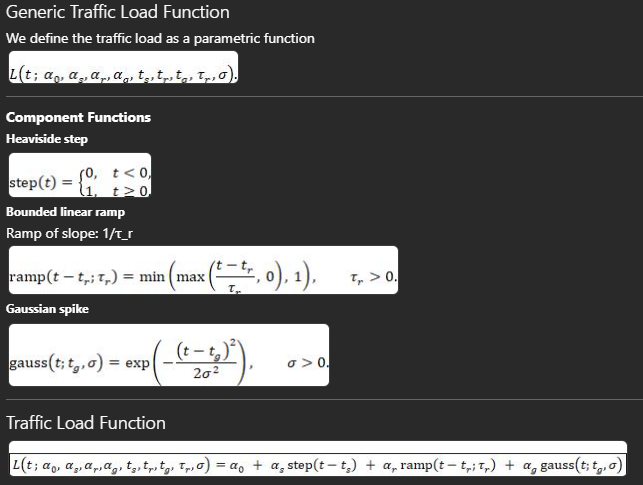

# Visualise Traffic Load Function

In [2]:
alpha_0, alpha_s, alpha_r, alpha_g, t_s, t_r, t_g, tau_r, sigma = 2000, 50000, 50000, 50000, 10, 20, 30, 20, 3
t_end = 50
load = TrafficLoad(alpha_0, alpha_s, alpha_r, alpha_g, t_s, t_r, t_g, tau_r, sigma)

(0.0, 50.0)

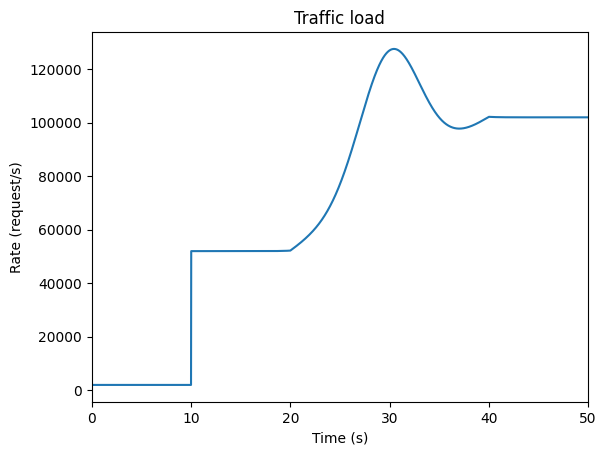

In [3]:
t = np.linspace(0, t_end, 5000)
l = [load(x) for x in t]

plt.plot(t, l)
plt.title("Traffic load")
plt.xlabel("Time (s)")
plt.ylabel("Rate (request/s)")
plt.xlim([0, t_end])

# Traffic Load generation

In [4]:
data = DataLoader().get_data_from_path('../data/conversations.json')
schedule = Scheduler().get_schedule_from_traffic_load_function(load, t_end, data, save_path='../schedules/traffic_load_func_demo.csv')
print('No. of requests =', len(schedule))

Simulation start
Simulation complete
No. of requests = 3477176


In [5]:
schedule

,Timestamp,Request tokens,Response tokens
0,0.000034,1979,490
1,0.000096,12654,20
2,0.002689,1348,631
3,0.002723,837,458
4,0.002890,2076,298
...,...,...,...
3477171,49.999971,345,205
3477172,49.999974,8032,84
3477173,49.999978,1348,631
3477174,49.999982,4540,2509


# Visualise generated traffic load

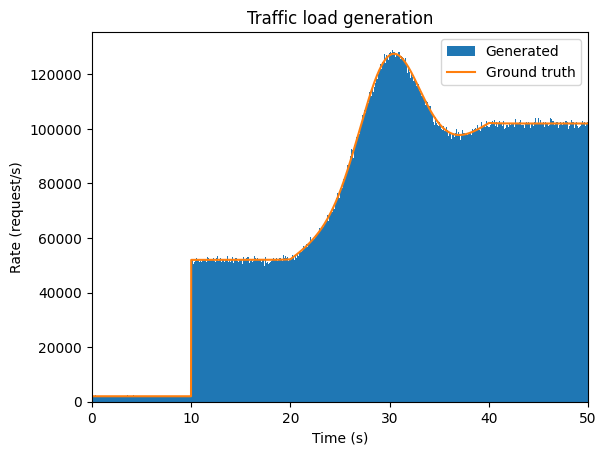

In [6]:
bins = 500
counts, edges = np.histogram(schedule.Timestamp, bins=bins)
_ = plt.stairs(bins * counts / t_end, edges=edges, fill=True, label="Generated")

t = np.linspace(0, t_end, 5000)
l = [load(x) for x in t]
plt.plot(t, l, label="Ground truth")
plt.title("Traffic load generation")
plt.xlabel("Time (s)")
plt.ylabel("Rate (request/s)")

plt.xlim([0, t_end])
plt.legend()